In [11]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = '_'.join(temp)
    return dataset_name

In [13]:
filename_path = 'data/Intra/train/rest_105923_1.h5'

with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    print(dataset_name)
    matrix = f.get(dataset_name)[()]
    print(type(matrix))
    print(matrix.shape)

rest_105923
<class 'numpy.ndarray'>
(248, 35624)


In [14]:
data = pd.DataFrame(matrix)
row_stats = pd.DataFrame({
    'mean': data.mean(axis=1),
    'std': data.std(axis=1)
})

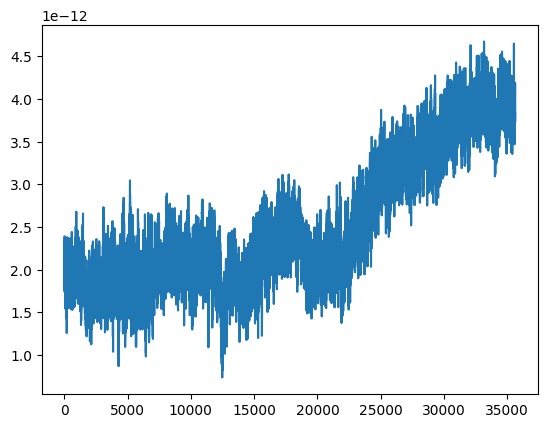

In [15]:
plt.plot(data.iloc[0])

In [16]:
# filename_path = 'data/Intra/train/task_working_memory_105923_1.h5'

# with h5py.File(filename_path, 'r') as f:
#     dataset_name = get_dataset_name(filename_path)
#     print(dataset_name)
#     matrix = f.get(dataset_name)[()]

# data = pd.DataFrame(matrix)
# row_stats = pd.DataFrame({
#     'mean': data.mean(axis=1),
#     'std': data.std(axis=1)
# })

# plt.plot(data.iloc[0])

3563

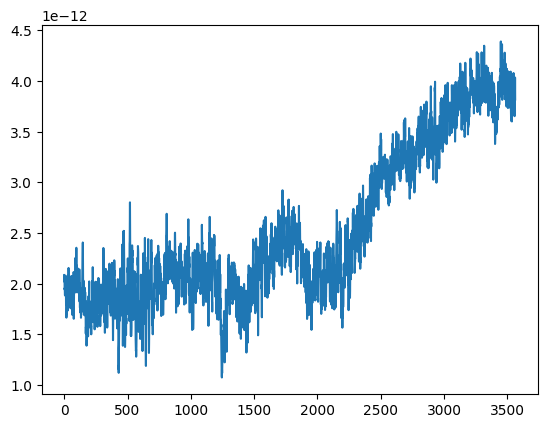

In [17]:
means = pd.Series(data.iloc[0].to_numpy()).groupby(lambda i: i // 10).mean()
plt.plot(means)
means.size

88536

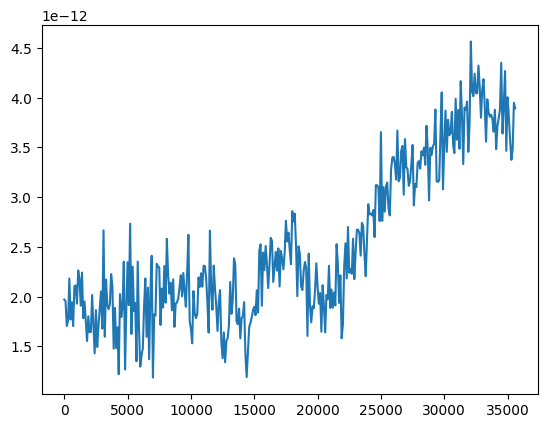

In [21]:
dropped_out = data.iloc[:, ::100]
plt.plot(dropped_out.iloc[0])
dropped_out.size

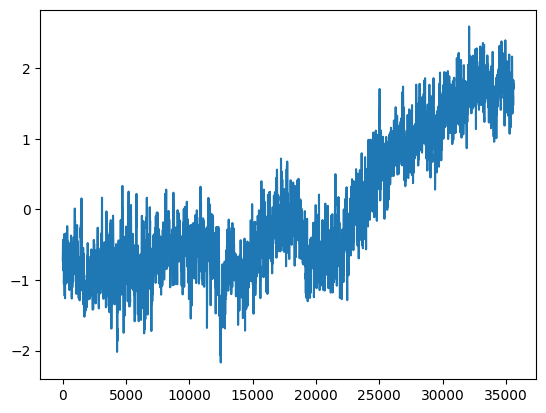

In [19]:
scaled = dropped_out.copy()
for i, row in dropped_out.iterrows():
    row_mean = row_stats.loc[i, 'mean']
    row_std = row_stats.loc[i, 'std']
    scaled.iloc[i] = (row - row_mean) / row_std
plt.plot(scaled.iloc[0])

task_motor_105923


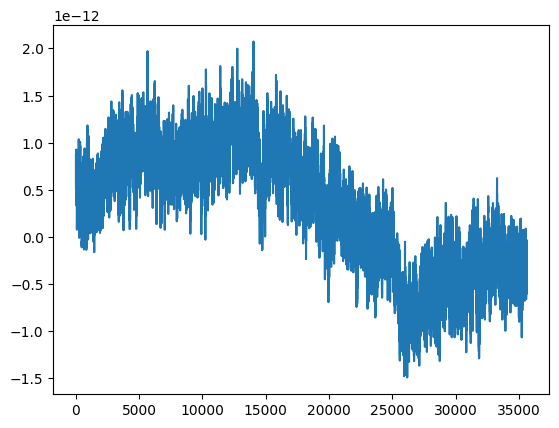

In [27]:
filename_path = 'data/Intra/train/task_motor_105923_5.h5'

with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    print(dataset_name)
    matrix = f.get(dataset_name)[()]

data = pd.DataFrame(matrix)
row_stats = pd.DataFrame({
    'mean': data.mean(axis=1),
    'std': data.std(axis=1)
})

plt.plot(data.iloc[0])

task_working_memory_105923


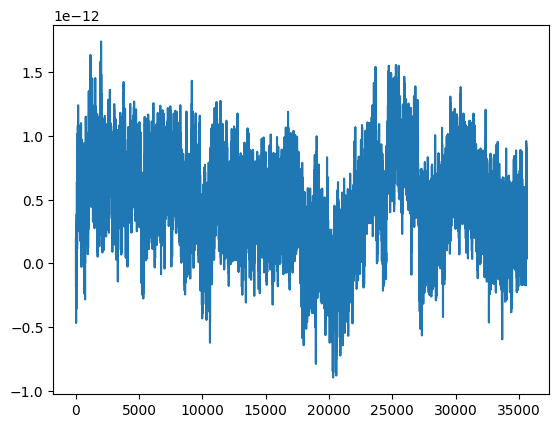

In [ ]:
filename_path = 'data/Intra/train/task_working_memory_105923_1.h5'

with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    print(dataset_name)
    matrix = f.get(dataset_name)[()]

data = pd.DataFrame(matrix)
row_stats = pd.DataFrame({
    'mean': data.mean(axis=1),
    'std': data.std(axis=1)
})

plt.plot(data.iloc[0])